# 6 Data Pre-Processing – Principal Component Analysis

**Note:** In the discussion below, recall that a **sample** is an individual spectrum (a column in a DataFrame), and a **feature** is a particular wavenumber (a row in a DataFrame). Each sample has many features associated with it.

Principal component analysis is a process that reduces the dimensionality of a dataset. This is achieved by reducing the number of features associated with all samples *via* a mathematical transformation.
<br>
<br>Dimensional reduction can speed the use of algorithms by only handing key data for processing and reducing computation. It also has the advantage of allowing data visualisation (plotting 100-dimensional data is much harder than 2-dimensional or 3-dimensional data).
<br>
<br>Principal component analysis transforms data into a new coordinate system so that each axis represents a direction in the dataspace with the most significant amount of variation, i.e. the best directions to look when trying to tell apart different samples.

Consider the following arbitrary dataset comprised of two discernable subsets:
![Picture2.png](attachment:Picture2.png)
<br>There is a good deal of variation in both x and y, but there is even more variation along a hybrid axis - the line of best fit:
![Picture3.png](attachment:Picture3.png)
<br>We can add a second perpendicular axis that captures the second-most important direction of data variation as well:
![Picture4.png](attachment:Picture4.png)

Redrawing these new axes gives the following new projection of the data:
![Picture5.png](attachment:Picture5.png)
Notice that in this new projection removal of the second (new y) axis still allows the two data subsets to be distinguished, i.e. by capturing the directions of most variation we plot fewer axes and still tell different subsets apart:
![Picture6.png](attachment:Picture6.png)
Consider how removal of the x axis in the new projection would not allow the two subsets to be distinguished since the new y axis captures less of the variation within the dataset.

**Extension - Mathematical Outline**
<br>
<br>The data is in an f × s matrix, with features (e.g. transmittances) as columns and samples (e.g. repeats/IR spectra) as rows.
<br>
<br>We seek a set of n lots of n-dimensional vectors (e.g. 3 lots of 3-dimensional vectors). Each vector has the form w=(w_1,…,w_n ). There are p such vectors: w_1,…,w_n. These vectors will be the new set of axes.
<br>
<br>Each original sample, s, is projected onto the vectors w (*via* s.w) in order to transform it into its new (principal component) coordinate system, giving a new transformed sample, t.
<br>
<br>How are the w vectors found? The vector w_1 is defined such that it is a line of best fit through the data; in other words, it is the vector along which there is the **maximum** variance in the dataset.
<br>
<br>The remaining p-1 vectors in w are constructed such that w forms an orthogonal set. A consequence of how we defined w_1 for the coordinate transform is that in our new coordinates, the first coordinate is the coordinate along which the variation, or spread, of the data is maximised. No other coordinate system would give such a big spread along any one axis. Similarly, w_2 is the axis along which the second most variance/spread can be put.
<br>
<br>As a result, the final coordinates, …,w_(n-2),w_(n-1),w_n, are the coordinates along which the data is the least spread/varied. Since there is such little variation along these axes (they account for very little of the variation/spread of the dataset), we can often safely get rid of them, i.e. reduce the dimensionality of the transformed dataset.

**Note:** Running this code will prevent some irrelevant errors popping up later on in the exercise.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

### 1 Principle Component Analysis (PCA) - 3 Dimensions

In [ ]:
import numpy as np
import pandas as pd
import C317

Mounted at /content/drive


In [ ]:
import importlib
importlib.reload(C317)

d = C317.load_spectra()
print(d)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       o-salicylaldehyde_4.txt  o-1-chloro-2-nitrobenzene_3.txt  \
630.0                 0.000186                         0.000212   
631.0                 0.000184                         0.000211   
632.0                 0.000178                         0.000209   
633.0                 0.000173                         0.000207   
634.0                 0.000171                         0.000204   
...                        ...                              ...   
876.0                 0.000218                         0.000257   
877.0                 0.000202                         0.000257   
878.0                 0.000179                         0.000258   
879.0                 0.000156                         0.000257   
880.0                 0.000139                         0.000256   

       o-salicylic acid_4.txt  o-guaiacol_3.txt  o-aminobenzylalco

In [ ]:
print(d.shape[0])

251


The `sklearn.decomposition` library contains a function `PCA()` which takes as an argument the number of principle components you want your data reduced to and generates a `PCA` object. (This is very similar to creating an array object using `numpy`, e.g. `numpy.array([x, ,y, x])`).
<br>
<br>The `PCA` object contains a method, `fit_transform()`, which takes data into the object, applies PCA, and returns the data as a `numpy` array.
<br>
<br>**Note:**
>PCA() is fussy and requires input to be formatted so that each sample is a different **row** in a DataFrame. This is currently not the format of the data that you have imported. Consider making use of the DataFrame attribute described here:
>
>https://pandas.pydata.org/pandas-docs/version/0.25.0/reference/api/pandas.DataFrame.T.html
>
>The output is also formatted so that each row corresponds to a separate sample.

The `numpy` array can then be transformed back into a DataFrame, swapping rows for columns and assigning the correct column headings as you have done in previous notebooks.
<br>
<br>**Note:**
>PCA transformation strips the column/row headings from the data handed to `fit_transform()`. So this information will not appear in the output. You will need to provide the column headings again when importing your reduced dataset back into a DataFrame.

In [ ]:
import sklearn.decomposition

pca = sklearn.decomposition.PCA(n_components = 3)
print(pca)

PCA(n_components=3)


In [ ]:
# from dictionary: df2_transposed = df2.T
pca_transposed = d.T
pca_array = pca.fit_transform(pca_transposed)
print(pca_array.shape)

(380, 3)


In [ ]:
import pandas as pd
import os
os.scandir("/content/drive/MyDrive/Raw_IR_Spectra")

pca_retransposed = pca_array.T
# recall: df = pd.DataFrame(data=[], index =[], columns=[])

column_names = []
for i in os.scandir("/content/drive/MyDrive/Raw_IR_Spectra"):
  column_names.append(i.name)

print(column_names)

pca_df = pd.DataFrame(pca_retransposed, columns = column_names)
print(pca_df)

['o-salicylaldehyde_4.txt', 'o-1-chloro-2-nitrobenzene_3.txt', 'o-salicylic acid_4.txt', 'o-guaiacol_3.txt', 'o-aminobenzylalcohol_3.txt', 'm-tolualdehyde_3.txt', 'o-bromotoluene_3.txt', 'm-toluoyl chloride_3.txt', 'p-acetoxybenzoic_2.txt', 'm-aminoacetophenone_1.txt', 'o-anthranilicacid_4.txt', 'm-tolualdehyde_4.txt', 'o-aspirin_5.txt', 'o-dicyanobenzene_3.txt', 'o-ethoxyphenol_5.txt', 'p-allylphenoxide_2.txt', 'o-fluorobenzaldehyde_5.txt', 'o-chlorobenzaldehyde_3.txt', 'o-toluidine_1.txt', 'm-diethoxybenzene_5.txt', 'm-toluenesulfonyl chloride_4.txt', 'p-hydroxybenzamide_1.txt', 'm-methyl o-toluate_5.txt', 'p-bromotoluene_3.txt', 'o-aminobenzylamine_3.txt', 'm-acetoxybenzoic_4.txt', 'm-nitrotoluene_3.txt', 'm-aminoacetophenone_4.txt', 'o-hydroxybenzonitrile_3.txt', 'o-guaiacol_5.txt', 'p-allylphenoxide_1.txt', 'o-fluorobenzaldehyde_2.txt', 'o-toluidine_4.txt', 'o-methylacetophenone_2.txt', 'o-dicyanobenzene_5.txt', 'p-bromoacetophenone_4.txt', 'p-cyanobenzaldehyde_1.txt', 'm-methyl o

Where previously the DataFrame contained hundreds of rows, each corresponding to a different wavenumber, you should now have a DataFrame with ~380 columns, and only 3 rows, i.e. the dimensions of the dataset have ben reduced to the 3 most significant components.
<br>
<br>

Now that we have our data down from hundreds of dimensions to 3 dimensions, we can plot the three principal components of each spectrum on a 3D graph. (Refer back to Notebook 2 if you cannot recall how to construct graphs in three dimensions.)

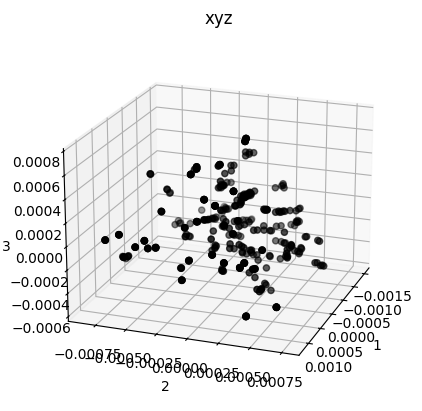

In [ ]:
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.axes3d as p3
%matplotlib inline

xdata = pca_df.iloc[0]
ydata = pca_df.iloc[1]
zdata = pca_df.iloc[2]

figure1 = plt.figure()
axes1 = figure1.add_subplot(projection="3d")
axes1.scatter(xdata, ydata, zdata, marker="o", c="black")

axes1.set_xlabel("1")
axes1.set_ylabel("2")
axes1.set_zlabel("3")
axes1.set_title("xyz")
# axes1.legend(["x", "y", "z"])

axes1.azim=20
axes1.elev=20
axes1.dist=20

plt.show()

While the principal components are now displayed, it is not currently possible to distinguish the three different subsets of data within the plot, i.e. *ortho*, *meta*, and *para* compounds. This can be accomplished by assigning a colour to each subset.
<br>
<br>As outlined in Notebook 2, each datapoint can be assigned its own colour by handing the `c` (colors) argument a list of colour names as strings.
<br>
<br>As you will see from the headings in your DataFrame, the .txt files that you have been provided with are titled with the substitution pattern as their first character (o, m, or p). The following steps will outline one method that could be employed to create a list of colours based on the titles of each .txt file:
>Create a list containing the heading of each column of the DataFrame
>
>While iterating through the list of headings, employ an `if`-`else` type statement to assign a particular colour based on the first character of each string in the list. *Hint:* Recall that strings can be treated as lists, i.e. `string[1]` will return the second character in a string.

In [ ]:
import pandas as pd
import os
os.scandir("/content/drive/MyDrive/Raw_IR_Spectra")

pca_retransposed = pca_array.T
# recall: df = pd.DataFrame(data=[], index =[], columns=[])

column_names = []
for i in os.scandir("/content/drive/MyDrive/Raw_IR_Spectra"):
  if i.name[0] == "o":
    column_names.append("red")
  elif i.name[0] == "m":
    column_names.append("blue")
  else:
    column_names.append("green")

pca_df = pd.DataFrame(pca_retransposed, columns = column_names)
print(pca_df)

        red       red       red       red       red      blue       red  \
0 -0.000849 -0.000447 -0.000650  0.000264 -0.001211  0.000308  0.000714   
1 -0.000827 -0.000170 -0.000150 -0.000794 -0.000081 -0.000210 -0.000715   
2  0.000180 -0.000037  0.000207 -0.000320 -0.000219  0.000486 -0.000010   

       blue     green      blue  ...     green     green     green     green  \
0 -0.000275 -0.000250 -0.000313  ...  0.000787  0.000342 -0.000373  0.000777   
1  0.000114  0.000321  0.000139  ...  0.000344  0.000117  0.000385  0.000289   
2  0.000717 -0.000047  0.000249  ... -0.000547 -0.000059 -0.000314 -0.000142   

      green     green     green     green     green     green  
0 -0.000086 -0.000152 -0.000282  0.000788 -0.000152 -0.000542  
1  0.000529  0.000595  0.000385  0.000343  0.000600  0.000105  
2 -0.000110 -0.000137  0.000124 -0.000548 -0.000146  0.000184  

[3 rows x 380 columns]


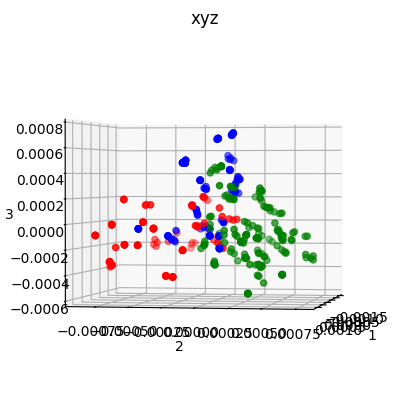

In [ ]:
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.axes3d as p3
%matplotlib inline

xdata = pca_df.iloc[0]
ydata = pca_df.iloc[1]
zdata = pca_df.iloc[2]

figure1 = plt.figure()
axes1 = figure1.add_subplot(projection="3d")
axes1.scatter(xdata, ydata, zdata, marker="o", c=pca_df.columns)

axes1.set_xlabel("1")
axes1.set_ylabel("2")
axes1.set_zlabel("3")
axes1.set_title("xyz")
# axes1.legend(["x", "y", "z"])

axes1.azim=10
axes1.elev=1
axes1.dist=10

plt.show()

---
### 2 Principle Component Analysis (PCA) - More Than 3 Dimensions

Reducing the dimensions of a dataset from hundreds of rows/features to just 3 can be very useful for visualisation, as illustrated above. However, it is often not the case that subsets of data can be separated using only a three principal component dataspace (above you saw that two subsets were much more well separated than the third).
<br>
<br> Reducing the dimensions of a dataset has the further advantage of limiting the extent of computation that needs to be carried out during analysis - consider how reducing 251 wavenumber entries per spectrum to 20 components per spectrum could stand to extensively decrease calculation times.
<br>
<br> So there is often a middle ground in data reduction *via* principal component analysis, not reducing the data so much that subsets cannot be distinguished, but enough to ease computational burden.

In [ ]:
import sklearn.decomposition
import pandas as pd
import os
os.scandir("/content/drive/MyDrive/Raw_IR_Spectra")

pca = sklearn.decomposition.PCA(n_components = 20)

pca_transposed = d.T
pca_array = pca.fit_transform(pca_transposed)

pca_retransposed = pca_array.T
# recall: df = pd.DataFrame(data=[], index =[], columns=[])

column_names = []
for i in os.scandir("/content/drive/MyDrive/Raw_IR_Spectra"):
  column_names.append(i.name)

pca_df = pd.DataFrame(pca_retransposed, columns = column_names)
print(pca_df)

    o-salicylaldehyde_4.txt  o-1-chloro-2-nitrobenzene_3.txt  \
0                 -0.000849                        -0.000447   
1                 -0.000827                        -0.000170   
2                  0.000180                        -0.000037   
3                 -0.000098                         0.000216   
4                  0.000221                         0.000097   
5                  0.000331                        -0.000463   
6                 -0.000040                        -0.000401   
7                 -0.000173                        -0.000320   
8                  0.000206                         0.000248   
9                  0.000183                        -0.000332   
10                 0.000043                        -0.000127   
11                -0.000053                         0.000103   
12                 0.000097                         0.000150   
13                -0.000143                         0.000010   
14                -0.000007             

         red       red       red       red       red      blue       red  \
0  -0.000849 -0.000447 -0.000650  0.000264 -0.001211  0.000308  0.000714   
1  -0.000827 -0.000170 -0.000150 -0.000794 -0.000081 -0.000210 -0.000715   
2   0.000180 -0.000037  0.000207 -0.000320 -0.000219  0.000486 -0.000010   
3  -0.000098  0.000216 -0.000342  0.000238  0.000103 -0.000157  0.000337   
4   0.000221  0.000097  0.000236 -0.000048 -0.000125 -0.000137  0.000018   
5   0.000331 -0.000463  0.000031 -0.000004 -0.000163 -0.000133  0.000021   
6  -0.000040 -0.000401  0.000258 -0.000064  0.000030 -0.000230  0.000148   
7  -0.000173 -0.000320  0.000061  0.000008  0.000035  0.000349  0.000218   
8   0.000206  0.000248 -0.000035 -0.000012 -0.000038  0.000094 -0.000104   
9   0.000183 -0.000332 -0.000028  0.000105  0.000088  0.000014  0.000016   
10  0.000043 -0.000127 -0.000068  0.000033 -0.000050  0.000044 -0.000003   
11 -0.000053  0.000103  0.000092  0.000008  0.000001  0.000201  0.000129   
12  0.000097

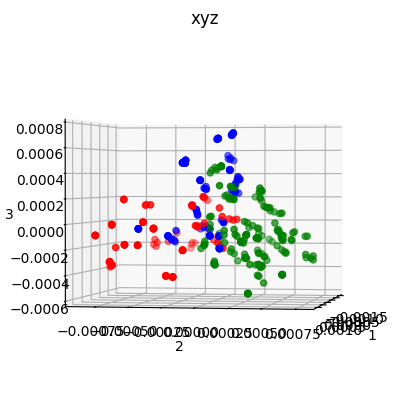

In [ ]:
import pandas as pd
import os
os.scandir("/content/drive/MyDrive/Raw_IR_Spectra")
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.axes3d as p3
%matplotlib inline

pca_retransposed = pca_array.T
# recall: df = pd.DataFrame(data=[], index =[], columns=[])

column_names = []
for i in os.scandir("/content/drive/MyDrive/Raw_IR_Spectra"):
  if i.name[0] == "o":
    column_names.append("red")
  elif i.name[0] == "m":
    column_names.append("blue")
  else:
    column_names.append("green")

pca_df = pd.DataFrame(pca_retransposed, columns = column_names)
print(pca_df)

xdata = pca_df.iloc[0]
ydata = pca_df.iloc[1]
zdata = pca_df.iloc[2]

figure1 = plt.figure()
axes1 = figure1.add_subplot(projection="3d")
axes1.scatter(xdata, ydata, zdata, marker="o", c=pca_df.columns)

axes1.set_xlabel("1")
axes1.set_ylabel("2")
axes1.set_zlabel("3")
axes1.set_title("xyz")
# axes1.legend(["x", "y", "z"])

axes1.azim=10
axes1.elev=1
axes1.dist=10

plt.show()

         red       red       red       red       red      blue       red  \
0  -0.000849 -0.000447 -0.000650  0.000264 -0.001211  0.000308  0.000714   
1  -0.000827 -0.000170 -0.000150 -0.000794 -0.000081 -0.000210 -0.000715   
2   0.000180 -0.000037  0.000207 -0.000320 -0.000219  0.000486 -0.000010   
3  -0.000098  0.000216 -0.000342  0.000238  0.000103 -0.000157  0.000337   
4   0.000221  0.000097  0.000236 -0.000048 -0.000125 -0.000137  0.000018   
5   0.000331 -0.000463  0.000031 -0.000004 -0.000163 -0.000133  0.000021   
6  -0.000040 -0.000401  0.000258 -0.000064  0.000030 -0.000230  0.000148   
7  -0.000173 -0.000320  0.000061  0.000008  0.000035  0.000349  0.000218   
8   0.000206  0.000248 -0.000035 -0.000012 -0.000038  0.000094 -0.000104   
9   0.000183 -0.000332 -0.000028  0.000105  0.000088  0.000014  0.000016   
10  0.000043 -0.000127 -0.000068  0.000033 -0.000050  0.000044 -0.000003   
11 -0.000053  0.000103  0.000092  0.000008  0.000001  0.000201  0.000129   
12  0.000097

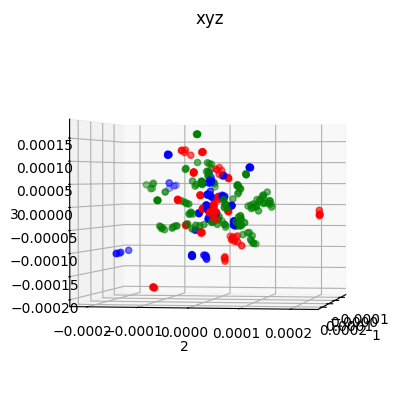

In [ ]:
# conclusion: getting worse as higher order principal components are explored.
import pandas as pd
import os
os.scandir("/content/drive/MyDrive/Raw_IR_Spectra")
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.axes3d as p3
%matplotlib inline

pca_retransposed = pca_array.T
# recall: df = pd.DataFrame(data=[], index =[], columns=[])

column_names = []
for i in os.scandir("/content/drive/MyDrive/Raw_IR_Spectra"):
  if i.name[0] == "o":
    column_names.append("red")
  elif i.name[0] == "m":
    column_names.append("blue")
  else:
    column_names.append("green")

pca_df = pd.DataFrame(pca_retransposed, columns = column_names)
print(pca_df)

xdata = pca_df.iloc[17]
ydata = pca_df.iloc[18]
zdata = pca_df.iloc[19]

figure1 = plt.figure()
axes1 = figure1.add_subplot(projection="3d")
axes1.scatter(xdata, ydata, zdata, marker="o", c=pca_df.columns)

axes1.set_xlabel("1")
axes1.set_ylabel("2")
axes1.set_zlabel("3")
axes1.set_title("xyz")
# axes1.legend(["x", "y", "z"])

axes1.azim=10
axes1.elev=1
axes1.dist=10

plt.show()

✏️ Write a function called `perform_pca()` which takes in a DataFrame (like the one produced with `load_spectra()`), and reduces it to `n` principal components (in addition to the DataFrame, you should be able to pass `n` to the function as a parameter). Add this new function to your C317 library.

In [ ]:
def perform_pca(n):
  pca = sklearn.decomposition.PCA(n_components = n)
  pca_transposed = d.T
  pca_array = pca.fit_transform(pca_transposed)
  pca_retransposed = pca_array.T
  column_names = []
  for i in os.scandir("/content/drive/MyDrive/Raw_IR_Spectra"):
    column_names.append(i.name)
  pca_df = pd.DataFrame(pca_retransposed, columns = column_names)
  return pca_df

In [ ]:
import importlib
importlib.reload(C317)

a = C317.perform_pca(20)
print(a)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    o-salicylaldehyde_4.txt  o-1-chloro-2-nitrobenzene_3.txt  \
0                 -0.000849                        -0.000447   
1                 -0.000827                        -0.000170   
2                  0.000180                        -0.000037   
3                 -0.000098                         0.000216   
4                  0.000221                         0.000097   
5                  0.000331                        -0.000463   
6                 -0.000040                        -0.000401   
7                 -0.000173                        -0.000320   
8                  0.000206                         0.000248   
9                  0.000183                        -0.000332   
10                 0.000043                        -0.000127   
11                -0.000053                         0.000103   
12                 0.000097            

In [ ]:
import importlib
importlib.reload(C317)

l = C317.load_spectra(0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       o-salicylaldehyde_4.txt  o-1-chloro-2-nitrobenzene_3.txt  \
630.0                 0.000186                         0.000212   
631.0                 0.000184                         0.000211   
632.0                 0.000178                         0.000209   
633.0                 0.000173                         0.000207   
634.0                 0.000171                         0.000204   
...                        ...                              ...   
876.0                 0.000218                         0.000257   
877.0                 0.000202                         0.000257   
878.0                 0.000179                         0.000258   
879.0                 0.000156                         0.000257   
880.0                 0.000139                         0.000256   

       o-salicylic acid_4.txt  o-guaiacol_3.txt  o-aminobenzylalco

---